In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Housing.csv")
print("Shape:", df.shape)
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0


In [4]:
median_price = df["price"].median()
df["high_price"] = (df["price"] > median_price).astype(int)
print("Median house price:", median_price)
print("\nTarget distribution:")
print(df["high_price"].value_counts())

Median house price: 4340000.0

Target distribution:
high_price
0    275
1    270
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["price", "high_price"])
y = df["high_price"]
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns
print("Numerical columns:", list(numeric_features))
print("Categorical columns:", list(categorical_features))

Numerical columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 12)
Testing data: (109, 12)


In [7]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8348623853211009


In [8]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        55
           1       0.83      0.83      0.83        54

    accuracy                           0.83       109
   macro avg       0.83      0.83      0.83       109
weighted avg       0.83      0.83      0.83       109



In [9]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
])
decision_tree_model.fit(X_train, y_train)
y_pred_dt = decision_tree_model.predict(X_test)
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7981651376146789


In [10]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81        55
           1       0.85      0.72      0.78        54

    accuracy                           0.80       109
   macro avg       0.80      0.80      0.80       109
weighted avg       0.80      0.80      0.80       109



In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_processed, y_train)
y_pred_nb = naive_bayes_model.predict(X_test_processed)
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8073394495412844


In [12]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.84      0.76      0.80        55
           1       0.78      0.85      0.81        54

    accuracy                           0.81       109
   macro avg       0.81      0.81      0.81       109
weighted avg       0.81      0.81      0.81       109



In [13]:
results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_nb)
    ]
})
results = results.sort_values("Accuracy", ascending=False)
results

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.834862,0.833333,0.833333,0.833333
2,Naive Bayes,0.807339,0.779661,0.851852,0.814159
1,Decision Tree,0.798165,0.847826,0.722222,0.780000


In [14]:
best_model = results.iloc[0]
print("Best Algorithm:", best_model["Algorithm"])
print("Best Accuracy:", round(best_model["Accuracy"], 4))

Best Algorithm: Logistic Regression
Best Accuracy: 0.8349


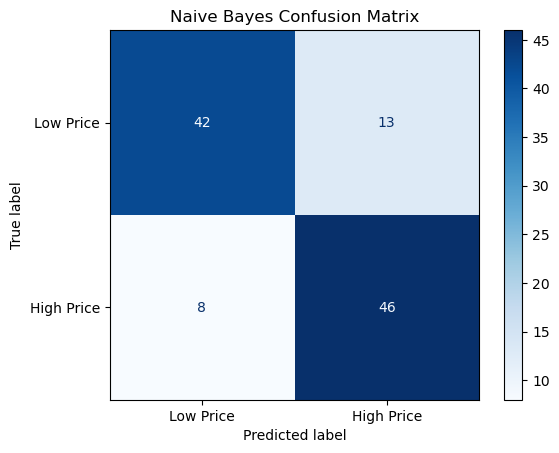

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Price", "High Price"]
)

disp.plot(cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")
plt.show()

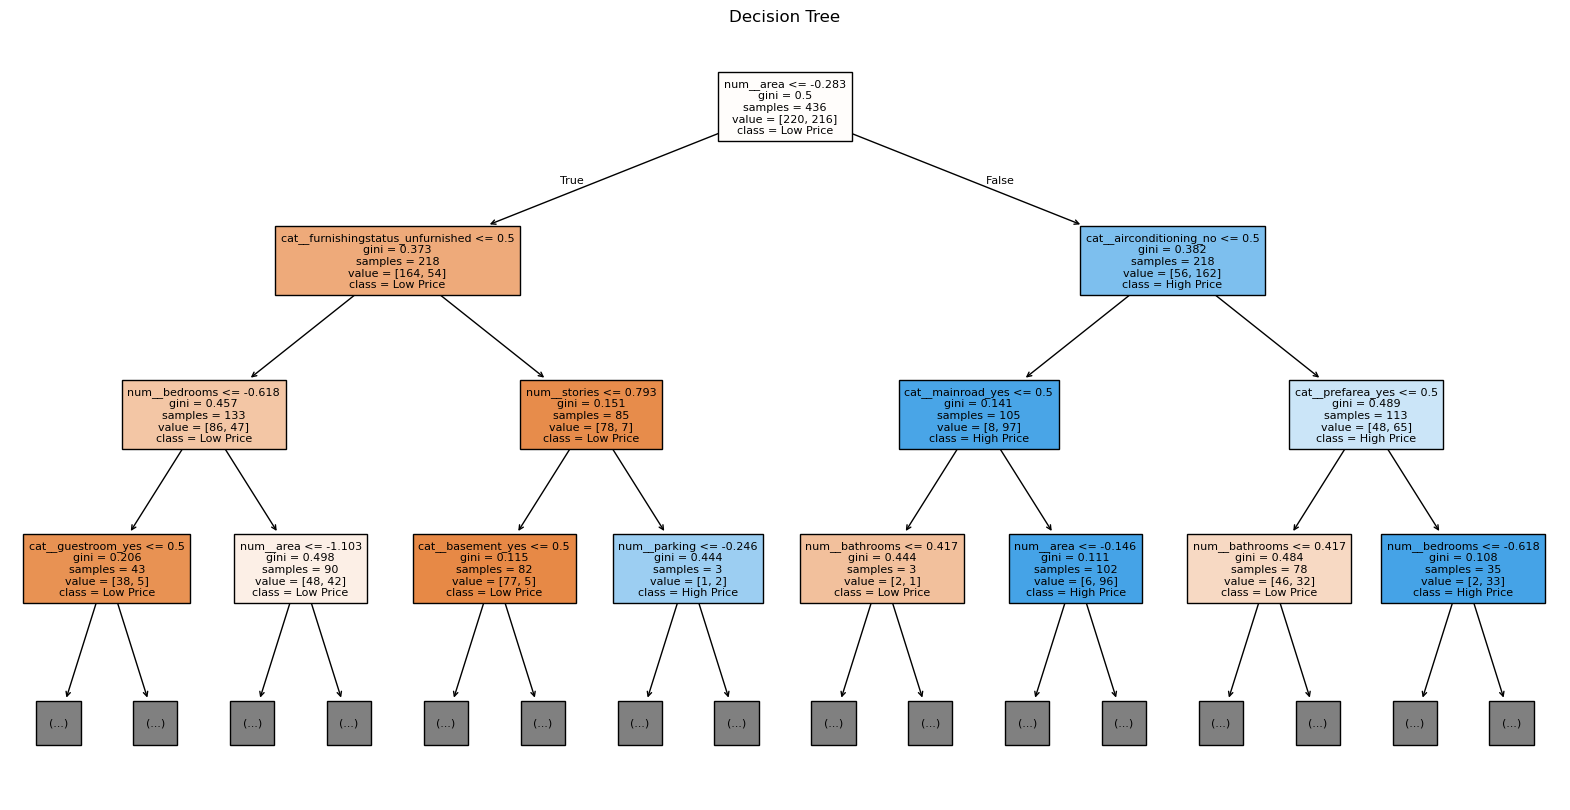

In [16]:
from sklearn.tree import plot_tree

tree_model = decision_tree_model.named_steps["model"]
feature_names = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Low Price", "High Price"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree")
plt.show()

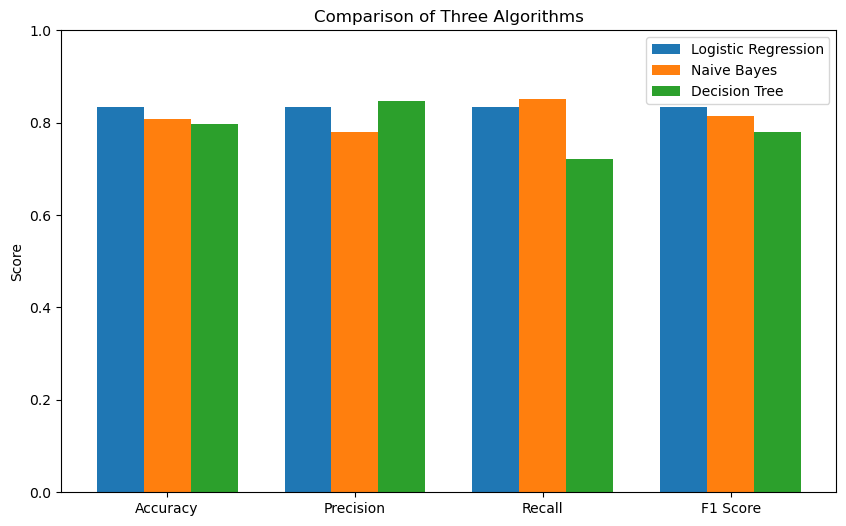

In [17]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
algorithms = results["Algorithm"].tolist()

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

for i, algorithm in enumerate(algorithms):
    values = results.loc[results["Algorithm"] == algorithm, metrics].values[0]
    plt.bar(x + (i - 1) * width, values, width, label=algorithm)

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Comparison of Three Algorithms")
plt.legend()
plt.show()